In [ ]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import fig_settings as fs

fs.set_fonts()

In [2]:
colors = ["#2d5d83", "#4f9bd9", "#077187", "#3dfaff", "#8b888e"]

In [3]:
nodes = pl.read_ndjson("data/deidentified_nodes.jsonl.gz")
n_active_nodes = len(
    nodes.filter(pl.col("active") == True)
)  # getting active node count
print(f"There are {n_active_nodes} active users.")

There are 36658723 active users.


shape: (3, 2)
┌────────┬──────────┐
│ active ┆ count    │
│ ---    ┆ ---      │
│ bool   ┆ u32      │
╞════════╪══════════╡
│ true   ┆ 36658723 │
│ false  ┆ 2168249  │
│ null   ┆ 788209   │
└────────┴──────────┘
shape: (4, 2)
┌─────────────┬──────────┐
│ status      ┆ count    │
│ ---         ┆ ---      │
│ str         ┆ u32      │
╞═════════════╪══════════╡
│ normal      ┆ 36658723 │
│ takendown   ┆ 1805687  │
│ null        ┆ 788209   │
│ deactivated ┆ 362562   │
└─────────────┴──────────┘


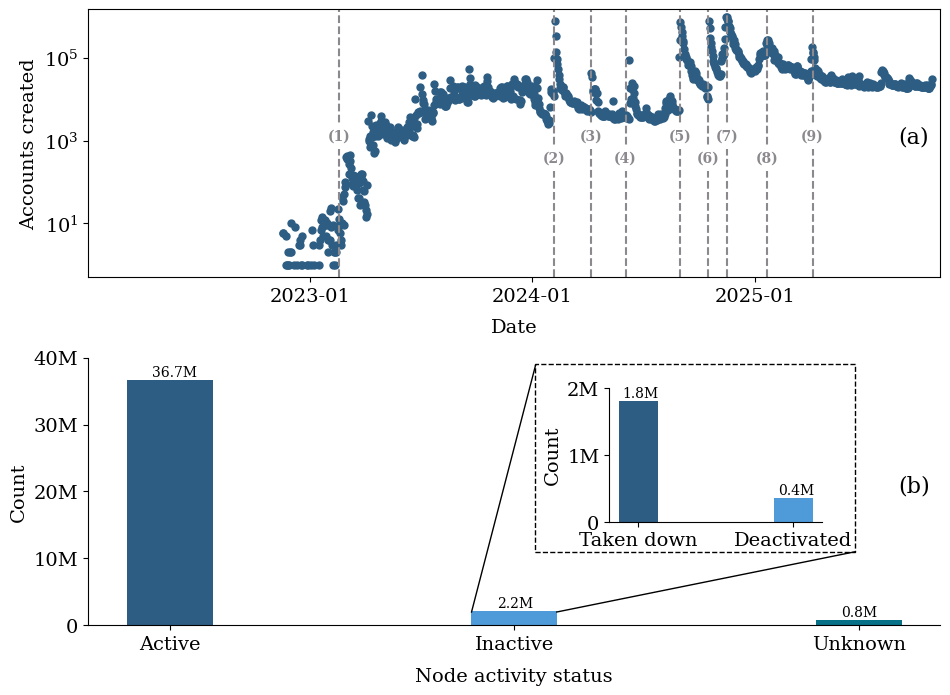

In [67]:
fig = plt.figure(figsize=(11, 8))
gs = GridSpec(2, 1, hspace=0.3)

text_x = 0.95
text_y = 0.5

# per-day node creation volume scatter plot
node_creation_dates = nodes["date-created"].value_counts(sort=True)
account_creation_volume = node_creation_dates["count"]
ax1 = fig.add_subplot(gs[0])
alpha = 0.3
text_height1 = 1000
text_height2 = 300
ymin = min(account_creation_volume) * 0.5
ymax = max(account_creation_volume) * 1.5
pad = 10

# Beta version open to the public
t_notable = datetime(2023, 2, 17)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height1,
    "(1)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

# Bluesky going public
t_notable = datetime(2024, 2, 6)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height2,
    "(2)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

# X blocking popular accounts in Brazil
t_notable = datetime(2024, 4, 6)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height1,
    "(3)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

# X changes its rules to formally allow adult & graphic content on the platform
# https://techcrunch.com/2024/06/03/x-tweaks-rules-to-formally-allow-adult-content/
t_notable = datetime(2024, 6, 2)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height2,
    "(4)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

# # X announces it will start hiding all likes
# # (https://www.theverge.com/2024/6/11/24176247/x-likes-hidden-private-rollout)
# t_notable = datetime(2024, 6, 11)
# plt.plot([t_notable, t_notable], [ymin, ymax], "-", color=colors[4], alpha=alpha)

# # announcement of starterpacks
# t_notable = datetime(2024, 6, 26)
# plt.plot([t_notable, t_notable], [ymin, ymax], "-", color=colors[4], alpha=alpha)

# banning of X in Brazil
t_notable = datetime(2024, 8, 30)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height1,
    "(5)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

# New X terms of service allowing blocked users to see posts
t_notable = datetime(2024, 10, 16)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height2,
    "(6)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

# New terms of service allowing X to train AI on user content
t_notable = datetime(2024, 11, 15)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height1,
    "(7)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

# Donald Trump sworn in as U.S. president
t_notable = datetime(2025, 1, 20)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height2,
    "(8)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

# Nationwide Hands Off protests in U.S.
t_notable = datetime(2025, 4, 5)
ax1.plot([t_notable, t_notable], [ymin, ymax], "--", color=colors[4])
tb = ax1.text(
    t_notable,
    text_height1,
    "(9)",
    horizontalalignment="center",
    fontweight="bold",
    color=colors[4],
)
tb.set_bbox(dict(facecolor="white", alpha=1, linewidth=0))

ax1.scatter(
    node_creation_dates["date-created"].str.to_datetime(),
    account_creation_volume,
    color=colors[0],
    s=25,
)
ax1.set_yscale("log")
ax1.minorticks_off()
ax1.set_xticks(
    [
        datetime(2023, 1, 1, 0, 0),
        (datetime(2024, 1, 1, 0, 0)),
        (datetime(2025, 1, 1, 0, 0)),
    ],
    ["2023-01", "2024-01", "2025-01"],
)
ax1.set_xlabel("Date", labelpad=pad)
ax1.set_ylabel("Accounts created")
ax1.set_ylim([ymin, ymax])
ax1.set_xlim([datetime(2022, 1, 1, 0, 0), datetime(2025, 11, 1, 0, 0)])
ax1.text(text_x, text_y, "(a)", fontsize=16, transform=ax1.transAxes)

# activity status bar chart
ax2 = fig.add_subplot(gs[1])
# make word formatting nicer
activity_words = {
    True: "Active",
    False: "Inactive",
}
xstart = -0.05  # for adding rounded node counts
ccount = 0
activity_counts = nodes["active"].value_counts(sort=True)
print(activity_counts)
for status, ct in activity_counts.iter_rows():
    status_word = activity_words.get(status, "Unknown")
    ax2.bar(status_word, ct, label=status_word, width=0.25, color=colors[ccount])
    ax2.text(xstart, ct + 500000, f"{round(ct/1e6, 1)}M")  # rounded node counts
    xstart += 1.0
    ccount += 1
ax2.set_ylim(0.0, 4e7)
ax2.set_xlabel("Node activity status", labelpad=pad)
ax2.set_ylabel("Count")
ax2.text(text_x, text_y, "(b)", fontsize=16, transform=ax2.transAxes)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_yticks([0, 1e7, 2e7, 3e7, 4e7], ["0", "10M", "20M", "30M", "40M"])

ax2ins = inset_axes(
    ax2,
    width="100%",
    height="100%",
    bbox_to_anchor=(0.6, 0.35, 0.25, 0.5),
    bbox_transform=ax2.transAxes,
    loc="lower left",
)

ax2.add_patch(
    plt.Rectangle(
        (0.525, 0.275), 0.375, 0.7, ls="--", ec="k", fc="none", transform=ax2.transAxes
    )
)

ax2ins.spines["top"].set_visible(False)
ax2ins.spines["right"].set_visible(False)
# making words nicer/formatted for the axis
status_words = {
    "normal": "Normal",
    "takendown": "Taken down",
    "deactivated": "Deactivated",
}
xstart = -0.1
ccount = 0
status_counts = nodes["status"].value_counts(sort=True)
print(status_counts)
for status, ct in status_counts.iter_rows():
    status_word = status_words.get(status, "Unknown")
    if status_word in {"Taken down", "Deactivated"}:
        ax2ins.bar(status_word, ct, label=status_word, width=0.25, color=colors[ccount])
        ax2ins.text(
            xstart, ct + 50000, f"{round(ct/1e6, 1)}M"
        )  # adding rounded counts to plot
        xstart += 1.0
        ccount += 1
ax2ins.set_yticks([0, 1e6, 2e6], ["0", "1M", "2M"])
ax2ins.set_ylabel("Count")
ax2ins.spines["top"].set_visible(False)
ax2ins.spines["right"].set_visible(False)

ax2.plot([0.45, 0.525], [0.05, 0.97], "-", color="k", lw=1, transform=ax2.transAxes)
ax2.plot([0.55, 0.9], [0.05, 0.275], "-", color="k", lw=1, transform=ax2.transAxes)

plt.savefig("figures/fig_node_creation_and_activity_stats.pdf", dpi=1000)